In [1]:
# Windows asyncio fix - MUST BE FIRST CELL
import sys
if sys.platform == 'win32':
    try:
        import nest_asyncio
        nest_asyncio.apply()
        print('✓ Windows asyncio fix applied')
    except ImportError:
        print('⚠ nest_asyncio not installed. Run: pip install nest-asyncio')


In [2]:
import os
import glob
import time
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import json
from pathlib import Path

print("XGBoost version:", xgb.__version__)


XGBoost version: 3.1.2


In [3]:
import sys
if sys.platform == 'win32':
    import asyncio
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
import gc
gc.collect()

26

In [4]:
# Configuration
CONFIG = {
    "station": "NYISO_TOTAL",
    "train_start": 2001,
    "train_end": 2021,
    "val_year": 2022,
    "test_years": [2023,2024, 2025],
    
    # Fixed XGBoost model parameters
    "model": {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "tree_method": "hist",
        "early_stopping_rounds": 20,
        "random_state": 42
    }
}

# Lag features for each aggregation (fixed - no weather features)
AGG_LAGS = {
    'raw': [1, 5, 15, 60],
    'five': [1, 7, 30],
    'quarter': [1, 7, 30],
    'hourly': [1, 24, 168],
    'daily': [1, 7, 30]
}

print("Configuration loaded")
print(f"Model params: {CONFIG['model']}")
print(f"Lag configs: {AGG_LAGS}")


Configuration loaded
Model params: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'early_stopping_rounds': 20, 'random_state': 42}
Lag configs: {'raw': [1, 5, 15, 60], 'five': [1, 7, 30], 'quarter': [1, 7, 30], 'hourly': [1, 24, 168], 'daily': [1, 7, 30]}


## Load NYISO Parquet Files

In [5]:
# Path to master parquet (we'll use only Load column for baseline)
from path_utils import MASTER_PARQUET as MASTER_PATH

print(f"Loading NYISO load data from: {MASTER_PATH}")
print(f"Note: Using master parquet but extracting only Load (no weather features)\n")


Loading NYISO load data from: /mnt/c/Users/Matt/Desktop/CS506/CS506_Project/1_LIB/master/master.parquet
Note: Using master parquet but extracting only Load (no weather features)



In [6]:
# Check what's available
import os
lib_path = Path("../../1_LIB")
print(f"Checking {lib_path.absolute()}")
print(f"Exists: {lib_path.exists()}")

if lib_path.exists():
    print("\nContents of 1_LIB:")
    for item in lib_path.iterdir():
        print(f"  - {item.name} ({'dir' if item.is_dir() else 'file'})")
    
    # Check for master parquet
    master_path = lib_path / "master" / "master.parquet"
    print(f"\nMaster parquet exists: {master_path.exists()}")
    if master_path.exists():
        print(f"  Path: {master_path}")


Checking /mnt/c/Users/Matt/Desktop/CS506/CS506_Project/../../1_LIB
Exists: False


In [7]:
# Load master parquet and extract only Load column (baseline - no weather)
print("Loading master parquet...")

df_all = pd.read_parquet(MASTER_PATH)

# Rename datetime column if needed
if 'datetime' in df_all.columns:
    df_all.rename(columns={'datetime': 'Time Stamp'}, inplace=True)

# Keep only Time Stamp and Load (no weather features for baseline)
if 'Time Stamp' in df_all.columns and 'Load' in df_all.columns:
    df_all = df_all[['Time Stamp', 'Load']]
    print(f"Loaded {len(df_all):,} rows (Load-only baseline)")
else:
    raise ValueError(f"Missing required columns. Found: {df_all.columns.tolist()}")


Loading master parquet...


Loaded 1,057,304 rows (Load-only baseline)


In [8]:
# Clean and process timestamp
df_all['Time Stamp'] = pd.to_datetime(df_all['Time Stamp'], errors='coerce')
df_all = df_all.dropna(subset=['Time Stamp'])
df_all = df_all.sort_values('Time Stamp')

print(f"After timestamp cleaning: {len(df_all):,} rows")


After timestamp cleaning: 1,057,304 rows


In [9]:
# Aggregate to total NYISO load at each timestamp (sum across zones)
df_all = df_all.groupby('Time Stamp')['Load'].sum()
df_all = df_all.to_frame(name='Load')
df_all.index.name = 'Time Stamp'

print(f"After aggregation: {len(df_all):,} rows")
print(f"\nDate range: {df_all.index.min()} to {df_all.index.max()}")


After aggregation: 1,057,304 rows

Date range: 2015-08-10 04:00:00+00:00 to 2025-10-01 03:55:00+00:00


In [10]:
# Clean impossible load values (0 or negative)
bad_mask = df_all['Load'] <= 0
if bad_mask.any():
    print(f"\n[CLEAN] Found {bad_mask.sum()} non-positive load values; interpolating...")
    df_all.loc[bad_mask, 'Load'] = np.nan
    df_all['Load'] = df_all['Load'].interpolate(method='time')
    df_all = df_all.dropna(subset=['Load'])
    print(f"After cleaning: {len(df_all):,} rows")

# Drop duplicate timestamps
df_all = df_all[~df_all.index.duplicated(keep='first')]

print("\nNYISO Total Load (first 10 rows):")
print(df_all.head(10))



[CLEAN] Found 27 non-positive load values; interpolating...
After cleaning: 1,057,304 rows

NYISO Total Load (first 10 rows):
                                  Load
Time Stamp                            
2015-08-10 04:00:00+00:00  1613.772727
2015-08-10 04:05:00+00:00  1602.554545
2015-08-10 04:10:00+00:00  1592.854545
2015-08-10 04:15:00+00:00  1585.218182
2015-08-10 04:20:00+00:00  1574.563636
2015-08-10 04:25:00+00:00  1569.463636
2015-08-10 04:30:00+00:00  1562.509091
2015-08-10 04:35:00+00:00  1559.663636
2015-08-10 04:40:00+00:00  1551.318182
2015-08-10 04:45:00+00:00  1544.245455


## Create Time Aggregations

In [11]:
if df_all.empty:
    raise ValueError("DataFrame is empty after loading and cleaning")

if 'Load' not in df_all.columns:
    raise KeyError(f"'Load' column not found. Available columns: {df_all.columns.tolist()}")

print("Creating time aggregations...")

# Create different temporal aggregations
raw = df_all[['Load']].copy()
five = raw.resample('5min').mean()
quarter = raw.resample('15min').mean()
hourly = raw.resample('1h').mean()
daily = raw.resample('1d').mean()

AGG_DFS = {
    'raw': raw,
    'five': five,
    'quarter': quarter,
    'hourly': hourly,
    'daily': daily
}

# Print shapes
print("\nAggregation sizes:")
for name, agg_df in AGG_DFS.items():
    print(f"  {name:8} → {len(agg_df):,} rows")


Creating time aggregations...



Aggregation sizes:
  raw      → 1,057,304 rows
  five     → 1,067,040 rows
  quarter  → 355,680 rows
  hourly   → 88,920 rows
  daily    → 3,706 rows


In [12]:
# Display samples
print("\nRaw data sample (5-minute resolution):")
print(raw.head(3))

print("\nDaily aggregation sample:")
print(daily.head(3))



Raw data sample (5-minute resolution):
                                  Load
Time Stamp                            
2015-08-10 04:00:00+00:00  1613.772727
2015-08-10 04:05:00+00:00  1602.554545
2015-08-10 04:10:00+00:00  1592.854545

Daily aggregation sample:
                                  Load
Time Stamp                            
2015-08-10 00:00:00+00:00  1899.865720
2015-08-11 00:00:00+00:00  1926.205019
2015-08-12 00:00:00+00:00  1913.993924


## XGBoost Training Function (Load-Only)

In [13]:
def run_xgboost(df, lags, agg_name):
    """
    Train XGBoost using only lag features (no weather).
    This is the baseline model.
    """
    start_time = time.time()

    df = df.copy().reset_index()
    df['year'] = df['Time Stamp'].dt.year

    # Create lag features from Load only
    for lag in lags:
        df[f'lag_{lag}'] = df['Load'].shift(lag)
    
    df = df.dropna()

    # Split data
    train = df[(df['year'] >= CONFIG['train_start']) & (df['year'] <= CONFIG['train_end'])]
    val = df[df['year'] == CONFIG['val_year']]
    test = df[df['year'].isin(CONFIG['test_years'])]

    # Features are only lag columns (no weather)
    lag_cols = [f'lag_{l}' for l in lags]
    
    X_train = train[lag_cols]
    y_train = train['Load']
    X_val = val[lag_cols]
    y_val = val['Load']
    X_test = test[lag_cols]
    y_test = test['Load']

    print(f"\n[{agg_name}] Train={len(train):,}, Val={len(val):,}, Test={len(test):,}")
    print(f"  Features: {len(lag_cols)} lag features only (no weather)")
    print(f"  Lags={lags}")

    # Train model
    model = xgb.XGBRegressor(**CONFIG['model'])
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=True
    )

    # Predictions
    y_val_pred = model.predict(X_val)
    y_pred = model.predict(X_test)

    # Validation metrics
    rmse_val = root_mean_squared_error(y_val, y_val_pred)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    r2_val = r2_score(y_val, y_val_pred)
    mask_val = y_val != 0
    mape_val = (abs((y_val[mask_val] - y_val_pred[mask_val]) / y_val[mask_val])).mean() * 100

    # Test metrics
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mask = y_test != 0
    mape = (abs((y_test[mask] - y_pred[mask]) / y_test[mask])).mean() * 100

    elapsed = time.time() - start_time

    print(f"  VAL  → MAPE={mape_val:.2f}% | MAE={mae_val:.2f} | RMSE={rmse_val:.2f} | R²={r2_val:.3f}")
    print(f"  TEST → MAPE={mape:.2f}% | MAE={mae:.2f} | RMSE={rmse:.2f} | R²={r2:.3f}")
    print(f"  Time → {elapsed:.2f}s")

    # Plot results
    plt.figure(figsize=(14, 6))
    plt.plot(test['Time Stamp'].values, y_test.values, label='Actual', alpha=0.6, linewidth=1.5)
    plt.plot(test['Time Stamp'].values, y_pred, label='Predicted', alpha=0.8, linewidth=1.5)
    plt.title(f"NYISO Load Prediction - {agg_name} (Load-Only Baseline)")
    plt.xlabel("Date")
    plt.ylabel("Load (MW)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "MAPE": mape,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Time_s": elapsed
    }

print("XGBoost training function defined")


XGBoost training function defined


## Train Models for All Aggregations


Training: RAW aggregation



[raw] Train=663,235, Val=105,092, Test=288,917
  Features: 4 lag features only (no weather)
  Lags=[1, 5, 15, 60]


[0]	validation_0-rmse:276.32627


[1]	validation_0-rmse:262.62006


[2]	validation_0-rmse:249.49674


...

[296]	validation_0-rmse:5.70072


[297]	validation_0-rmse:5.69979


[298]	validation_0-rmse:5.69858


[299]	validation_0-rmse:5.69709


  VAL  → MAPE=0.27% | MAE=4.24 | RMSE=5.70 | R²=1.000
  TEST → MAPE=0.28% | MAE=4.35 | RMSE=6.05 | R²=1.000
  Time → 3.90s


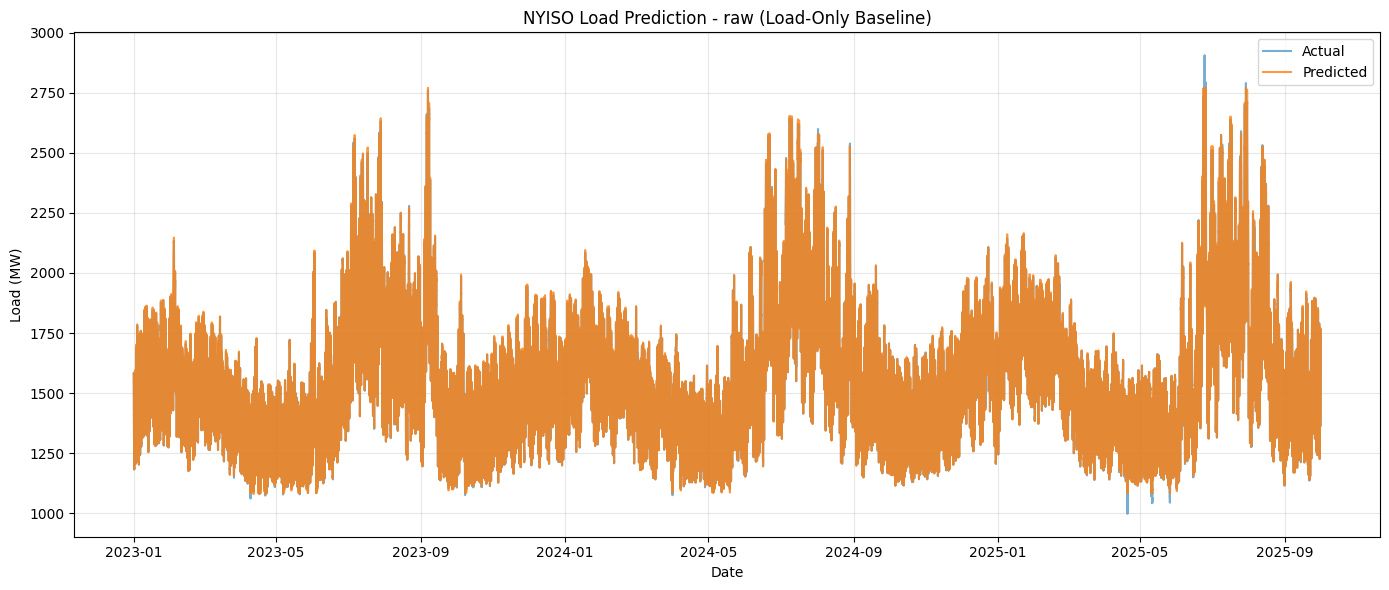


Training: FIVE aggregation

[five] Train=662,711, Val=105,027, Test=288,761
  Features: 3 lag features only (no weather)
  Lags=[1, 7, 30]
[0]	validation_0-rmse:276.31612


[1]	validation_0-rmse:262.50679


[2]	validation_0-rmse:249.52250


[3]	validation_0-rmse:237.05115


[4]	validation_0-rmse:225.20511


...

[296]	validation_0-rmse:7.41076


[297]	validation_0-rmse:7.40918


[298]	validation_0-rmse:7.40546


[299]	validation_0-rmse:7.40497


  VAL  → MAPE=0.36% | MAE=5.63 | RMSE=7.40 | R²=0.999
  TEST → MAPE=0.37% | MAE=5.75 | RMSE=7.76 | R²=0.999
  Time → 3.83s


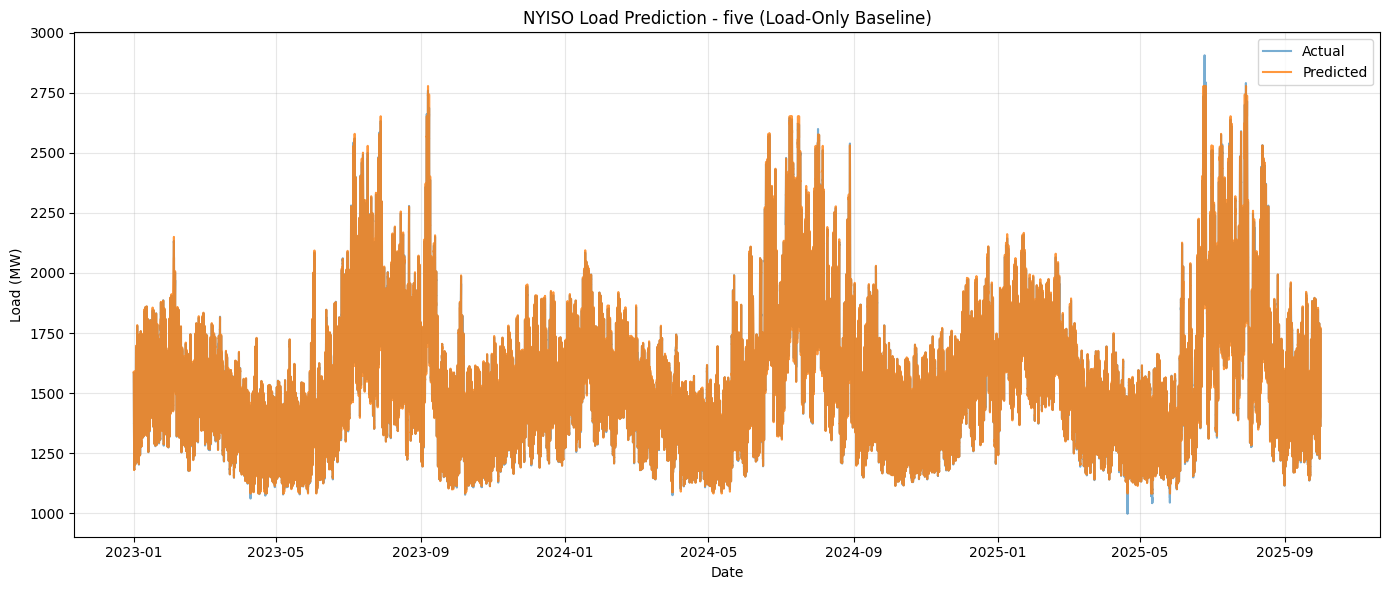


Training: QUARTER aggregation

[quarter] Train=220,957, Val=35,027, Test=96,273
  Features: 3 lag features only (no weather)
  Lags=[1, 7, 30]
[0]	validation_0-rmse:276.30732


[1]	validation_0-rmse:262.54206


[2]	validation_0-rmse:250.91019


[3]	validation_0-rmse:238.43452


[4]	validation_0-rmse:226.58951


...

[296]	validation_0-rmse:10.78411

[297]	validation_0-rmse:10.77818


[298]	validation_0-rmse:10.76821


[299]	validation_0-rmse:10.76440


  VAL  → MAPE=0.46% | MAE=7.52 | RMSE=10.76 | R²=0.999
  TEST → MAPE=0.51% | MAE=8.13 | RMSE=11.73 | R²=0.998
  Time → 2.62s


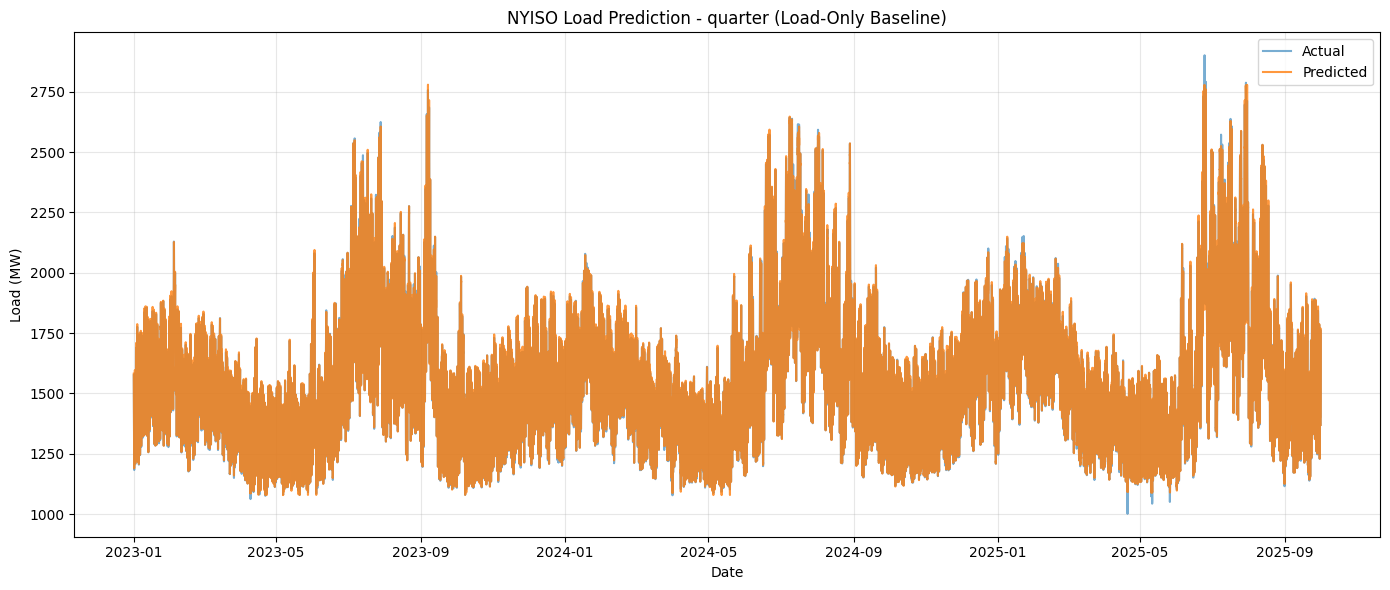


Training: HOURLY aggregation

[hourly] Train=54,712, Val=8,756, Test=24,040
  Features: 3 lag features only (no weather)
  Lags=[1, 24, 168]
[0]	validation_0-rmse:276.41538


[1]	validation_0-rmse:263.18177


[2]	validation_0-rmse:251.96051


[3]	validation_0-rmse:239.99643


[4]	validation_0-rmse:228.64652


...

[296]	validation_0-rmse:50.73063


[297]	validation_0-rmse:50.73198


[298]	validation_0-rmse:50.73131


[299]	validation_0-rmse:50.73078


  VAL  → MAPE=2.51% | MAE=39.86 | RMSE=50.72 | R²=0.969
  TEST → MAPE=2.55% | MAE=39.86 | RMSE=50.35 | R²=0.968
  Time → 2.14s


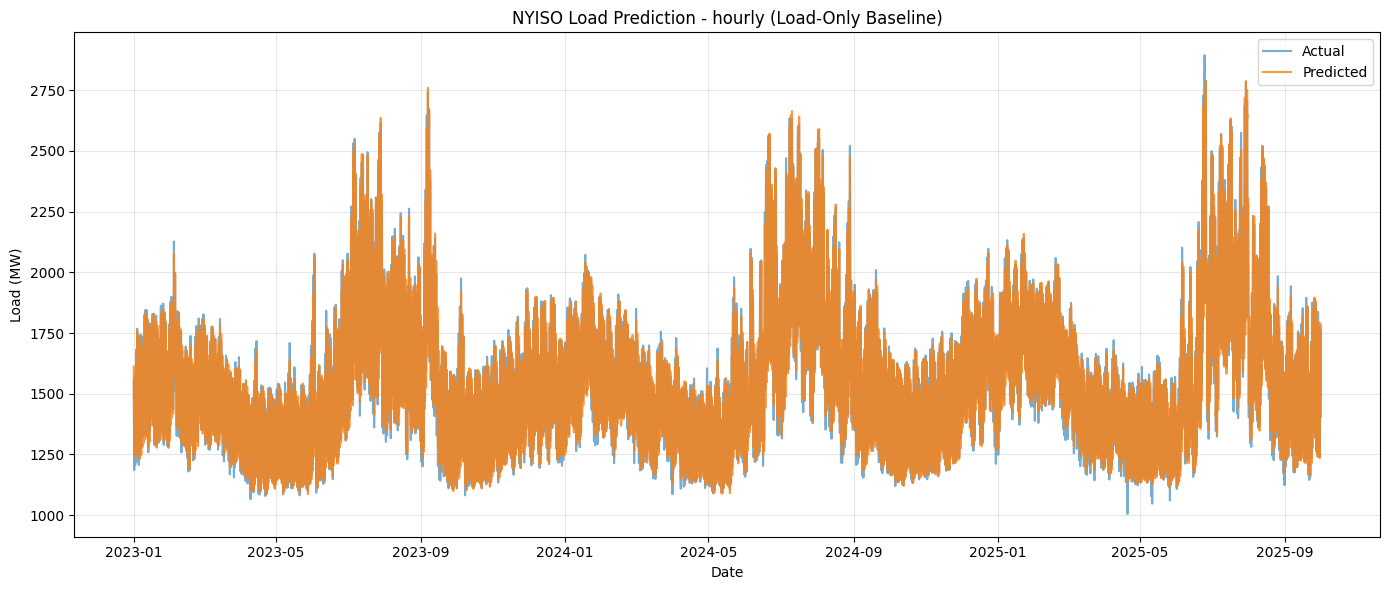


Training: DAILY aggregation

[daily] Train=2,234, Val=365, Test=1,005
  Features: 3 lag features only (no weather)
  Lags=[1, 7, 30]
[0]	validation_0-rmse:219.73666


[1]	validation_0-rmse:211.26847


[2]	validation_0-rmse:205.04020


[3]	validation_0-rmse:197.21958


[4]	validation_0-rmse:189.87016


...

[95]	validation_0-rmse:92.38704


[96]	validation_0-rmse:92.36980


[97]	validation_0-rmse:92.37793


[98]	validation_0-rmse:92.38502

  VAL  → MAPE=4.31% | MAE=69.63 | RMSE=92.14 | R²=0.834
  TEST → MAPE=4.49% | MAE=71.00 | RMSE=96.33 | R²=0.814
  Time → 0.63s


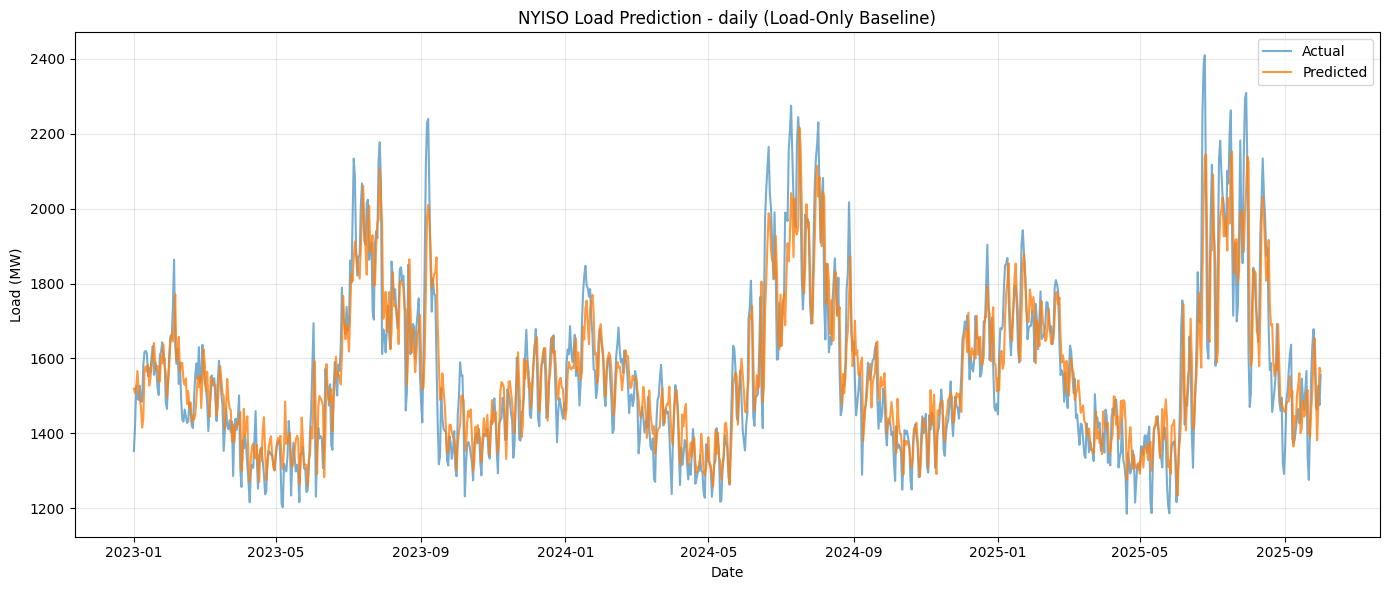



Total runtime: 17.73 seconds (0.30 minutes)


In [14]:
total_start = time.time()

results = {}

for agg_name, agg_df in AGG_DFS.items():
    print(f"\n{'='*70}")
    print(f"Training: {agg_name.upper()} aggregation")
    print(f"{'='*70}")
    
    lags = AGG_LAGS.get(agg_name, [1, 7, 30])
    metrics = run_xgboost(agg_df, lags=lags, agg_name=agg_name)
    results[agg_name] = metrics

total_time = time.time() - total_start
print(f"\n\nTotal runtime: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")


## Results Summary

In [15]:
# Create results DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df[['MAPE', 'MAE', 'RMSE', 'R2', 'Time_s']]

print("\n" + "="*70)
print("FINAL RESULTS SUMMARY - BASELINE (NYISO Load-Only, No Weather)")
print("="*70)
print(results_df.round(4))



FINAL RESULTS SUMMARY - BASELINE (NYISO Load-Only, No Weather)
           MAPE      MAE     RMSE      R2  Time_s
raw      0.2790   4.3467   6.0503  0.9995  3.8953
five     0.3717   5.7476   7.7563  0.9992  3.8276
quarter  0.5075   8.1314  11.7281  0.9983  2.6226
hourly   2.5533  39.8644  50.3545  0.9677  2.1440
daily    4.4864  70.9980  96.3342  0.8137  0.6252


In [16]:
# Display lag configurations used
print("\n" + "="*70)
print("LAG CONFIGURATIONS (Fixed)")
print("="*70)
for agg_name, lags in AGG_LAGS.items():
    print(f"  {agg_name:8} → {lags}")



LAG CONFIGURATIONS (Fixed)
  raw      → [1, 5, 15, 60]
  five     → [1, 7, 30]
  quarter  → [1, 7, 30]
  hourly   → [1, 24, 168]
  daily    → [1, 7, 30]


In [17]:
from pathlib import Path
import os

# Save results to JSON
output_file = "results_old.json"
with open(output_file, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n✓ Saved baseline results to: {output_file}")
print("\nThis file will be used for comparison with the weather-enhanced model")



✓ Saved baseline results to: results_old.json

This file will be used for comparison with the weather-enhanced model


## Performance Analysis

In [18]:
# Analyze which aggregation performs best
print("\n" + "="*70)
print("BEST PERFORMING AGGREGATION (by metric)")
print("="*70)

for metric in ['MAPE', 'MAE', 'RMSE']:
    best_agg = results_df[metric].idxmin()
    best_val = results_df.loc[best_agg, metric]
    print(f"{metric:5} → {best_agg:8} ({best_val:.4f})")

# R² - higher is better
best_agg = results_df['R2'].idxmax()
best_val = results_df.loc[best_agg, 'R2']
print(f"R²    → {best_agg:8} ({best_val:.4f})")



BEST PERFORMING AGGREGATION (by metric)
MAPE  → raw      (0.2790)
MAE   → raw      (4.3467)
RMSE  → raw      (6.0503)
R²    → raw      (0.9995)


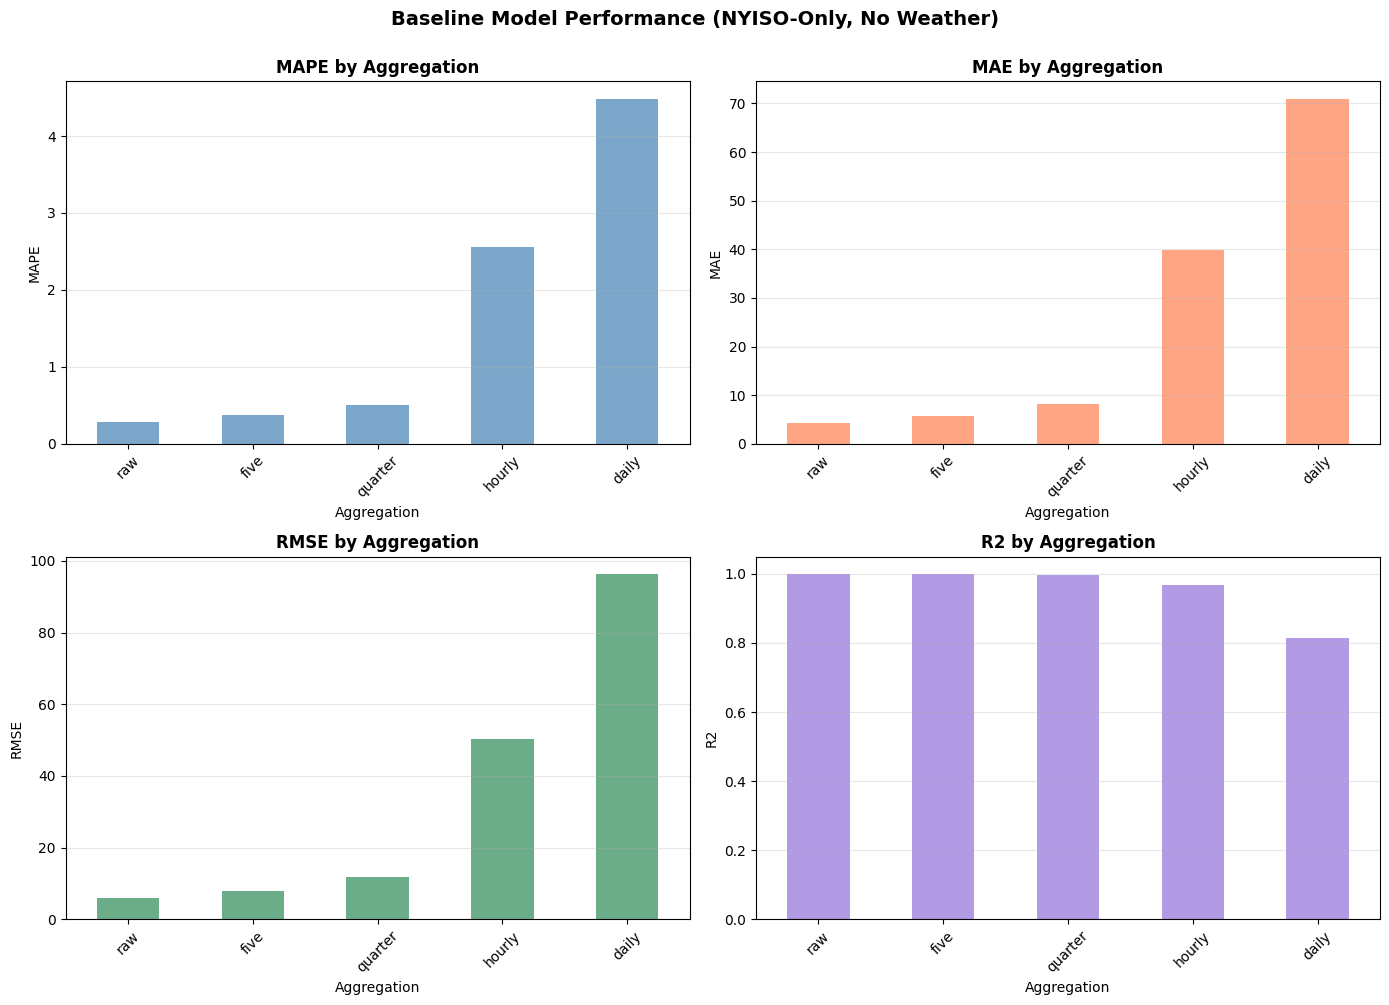


✓ Saved performance plot to: baseline_performance.png


In [19]:
# Visualize performance across aggregations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics_to_plot = ['MAPE', 'MAE', 'RMSE', 'R2']
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax = axes[i]
    results_df[metric].plot(kind='bar', ax=ax, color=color, alpha=0.7)
    ax.set_title(f'{metric} by Aggregation', fontsize=12, weight='bold')
    ax.set_xlabel('Aggregation', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Baseline Model Performance (NYISO-Only, No Weather)', 
             fontsize=14, weight='bold', y=1.00)
plt.tight_layout()
plt.savefig('baseline_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved performance plot to: baseline_performance.png")
